# Global Ads Performance: Advanced Exploratory Data Analysis

**Google Ads · Meta Ads · TikTok Ads | 1,800 campaigns | 2024**

This notebook examines the complete advertising funnel, from impressions and clicks to spend, conversions, revenue, and ROAS. The goal is to identify reliable performance patterns while separating descriptive evidence from causal claims.

> **Dataset context:** This is a synthetic dataset. The analysis demonstrates a real marketing-analytics workflow, but its platform rankings should not be treated as real-world benchmarks.

>**Dataset:**
1,800 ad campaigns (2024) across **Google Ads, Meta Ads, TikTok Ads** | 4 campaign types  (Search, Display, Video, Shopping) | 5 industries (Fintech, EdTech, Healthcare, SaaS, E-commerce) | 7 countries (USA, UK, UAE, Germany, Canada, India, Australia)
*It tracks the full ad funnel: ad shown → clicked → money spent → conversion → revenue.*


## Questions Answered 

1. Is the dataset complete, valid, and internally consistent?
2. How are campaign volumes, costs, and returns distributed?
3. Which funnel relationships are mechanical, and which are informaticve?
4. Is there evidence of trend, seasonality, or weekday performance?
5. Does efficiency decline as campaign spend increases?
6. Which campaigns deserve review because of unusally high or low ROAS?

**Methodology:** Aggregated CTR, CPC, CPA, and ROAS are calculated as ratios of totals. This prevents small campaigns from influencing portfolio KPIs as much as large campaigns.

## Column glossary


| Column | Meaning | Example |
|---|---|---|
| `date` | Day of activity | 2024-01-21 |
| `platform` | Where the ad ran | Google Ads |
| `campaign_type` | Ad format | Search |
| `industry` | Advertiser's sector | Fintech |
| `country` | Target market | UAE |
| `impressions` | Times the ad was shown | 59,886 people saw it |
| `clicks` | Times it was clicked | 2,113 clicked |
| `CTR` | clicks ÷ impressions -> how appealing the ad is | 0.0353 → 3.5% of viewers clicked |
| `CPC` | ad_spend ÷ clicks -> cost per click | $1.26 per click |
| `ad_spend` | Total money spent | \$2,662.38  |  
| `conversions` | Purchases/signups after clicking | 159 converted |
| `CPA` | ad_spend ÷ conversions -> cost per customer | \$16.74 to win each customer |
| `revenue` | Money earned from the campaign | \$4,803.43 |
| `ROAS` | revenue ÷ ad_spend -> return per \$1 spent | 1.8 → \\$1.80 back per \$1 (>1 = profit) |

-------------------------

>**Columns explained**
Using this real row as the example: Google Ads, Search, Fintech, UAE - 59,886 impressions, 2,113 clicks, spend \$2,662, 159 conversions, revenue \$4,803.

# Setup and data loading

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style="whitegrid", palette='deep')
plt.rcParams.update({"figure.dpi":100, "axes.titleweight":"bold"})
pd.set_option('display.float_format', lambda value: f"{value:,.3f}")

RANDOM_SEED = 42 
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
df = pd.read_csv('global_ads_performance_dataset.csv', parse_dates=['date'])
print(df.shape)

(1800, 14)


In [3]:
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.035,1.260,"2,662.380",159,16.740,"4,803.430",1.800
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.038,1.180,"6,159.600",411,14.990,"64,126.680",10.410
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.065,0.850,"5,092.350",267,19.070,"10,489.070",2.060
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.071,1.320,"7,834.200",296,26.470,"50,505.070",6.450
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.049,1.930,"8,663.770",107,80.970,"3,369.530",0.390


## 1. Data Quality Audit

Let's check completeness, duplicates, types, date coverage and **internal consistency**: 

Also the derived metrics (`CTR`, `CPC`, `CPA`,`ROAS`) must agree with the raw columns they're computed from. 

In [8]:
audit = pd.DataFrame(
    {
        'dtype' : df.dtypes.astype(str), 
        'nulls' : df.isna().sum(),
        'unique': df.nunique()
    }
)

print(audit)

                        dtype  nulls  unique
date           datetime64[us]      0     360
platform                  str      0       3
campaign_type             str      0       4
industry                  str      0       5
country                   str      0       7
impressions             int64      0    1790
clicks                  int64      0    1616
CTR                   float64      0     624
CPC                   float64      0     327
ad_spend              float64      0    1800
conversions             int64      0     518
CPA                   float64      0    1634
revenue               float64      0    1798
ROAS                  float64      0     999


In [9]:
print('Duplicated rows: ', df.duplicated().sum())
print('Date Coverage: ', df.date.min().date(), ' ---> ', df.date.max().date(), ' | ', df.date.nunique(), 'distinct days.')

Duplicated rows:  0
Date Coverage:  2024-01-01  --->  2024-12-30  |  360 distinct days.


**Notes**
- Each campign has different ad_spend 
- Zero nulls and No duplicates rows 
- Correct data types 
- Full-year coverage 

**So no cleaning required** 

In [ ]:
# Recompute each derived metric and measure max deviation

checks = {
     'CTR' : df.clicks / df.impressions - df.CTR, 
     'CPC' : df.ad_spend / df.clicks - df.CPC, 
     'CPA' : df.ad_spend / df.conversions - df.CPA,
     'ROAS': df.revenue / df.ad_spend - df.ROAS
}


In [27]:
metrics = list(checks.keys())
# print(metrics)
 

dev_summary = pd.DataFrame(
    {m:[checks[m].max(), checks[m].min(), checks[m].mean(), checks[m].abs().max()] for m in metrics}, 
    index=['max', 'min', 'mean', 'abs_max']
)

print(dev_summary)

           CTR    CPC    CPA   ROAS
max      0.000  0.000  0.005  0.005
min     -0.000 -0.000 -0.005 -0.005
mean    -0.000  0.000 -0.000 -0.000
abs_max  0.000  0.000  0.005  0.005


**All deviations are rounding-level -> derived columns are trustworthy.**

## 2. Univariate Analysis, Distributions & Skew

Money metrics (spend, revenue, ROAS) are usually right-skewed  
* That matters for both visualization and later modeling. 

In [28]:
num_cols = ['impressions','clicks','CTR','CPC','ad_spend','conversions','CPA','revenue','ROAS']

print(df[num_cols].describe().T)

                count        mean        std       min        25%         50%  \
impressions 1,800.000 102,919.019 55,740.901 5,059.000 54,948.000 103,653.000   
clicks      1,800.000   3,962.676  2,941.858    91.000  1,678.000   3,318.000   
CTR         1,800.000       0.038      0.017     0.009      0.025       0.036   
CPC         1,800.000       1.573      0.801     0.280      0.950       1.460   
ad_spend    1,800.000   6,171.527  5,776.997    58.000  1,966.588   4,393.860   
conversions 1,800.000     181.562    171.424     2.000     59.000     130.000   
CPA         1,800.000      46.609     41.186     4.800     20.203      33.375   
revenue     1,800.000  30,101.850 34,560.033   142.690  7,275.757  18,362.965   
ROAS        1,800.000       6.450      6.591     0.130      2.170       4.295   

                    75%         max  
impressions 150,470.250 199,650.000  
clicks        5,628.000  16,660.000  
CTR               0.050       0.096  
CPC               2.050       3.950  

Skewness measures how lopsided a distribution is. Whether the values pile up on one side with a long tail stretching out to the other.
* skew ≈ 0 means symmetric (like a bell curve). 
* Positive skew means a long tail to the right: most values are small-to-moderate, but a few are enormous. 
* Negative means the tail points left. 
* Rough rule: |skew| < 0.5 is basically symmetric, 0.5–1 is moderate, > 1 is strong.

We can see skew without ever computing it, just by comparing `mean` vs. `median (50%)`: 

* `revenue`:  mean $30,102 but median $18,363. The mean is 64% higher than the median. That happens because a few big campaigns (max $295k, nearly 10x the mean!) drag the mean up. So half of all campaigns earn less than $18k.
* `ROAS`: mean 6.45, median 4.30, max 49. The "average ROAS" is not what a typical one gets ~4.3.
* `Impressions`: essentially zero skew (mean ≈ median), So well behaved. 

`mean` ≫ `median` → `right-skewed`; the bigger the gap, the stronger the skew.

In [30]:
skew = df[num_cols].skew().sort_values(ascending=False)
print('\nSkewness (>1 = strongly right-skewed):')
print(skew)


Skewness (>1 = strongly right-skewed):
revenue        2.471
ROAS           2.391
CPA            2.285
conversions    1.819
ad_spend       1.673
clicks         1.113
CPC            0.637
CTR            0.626
impressions   -0.015
dtype: float64


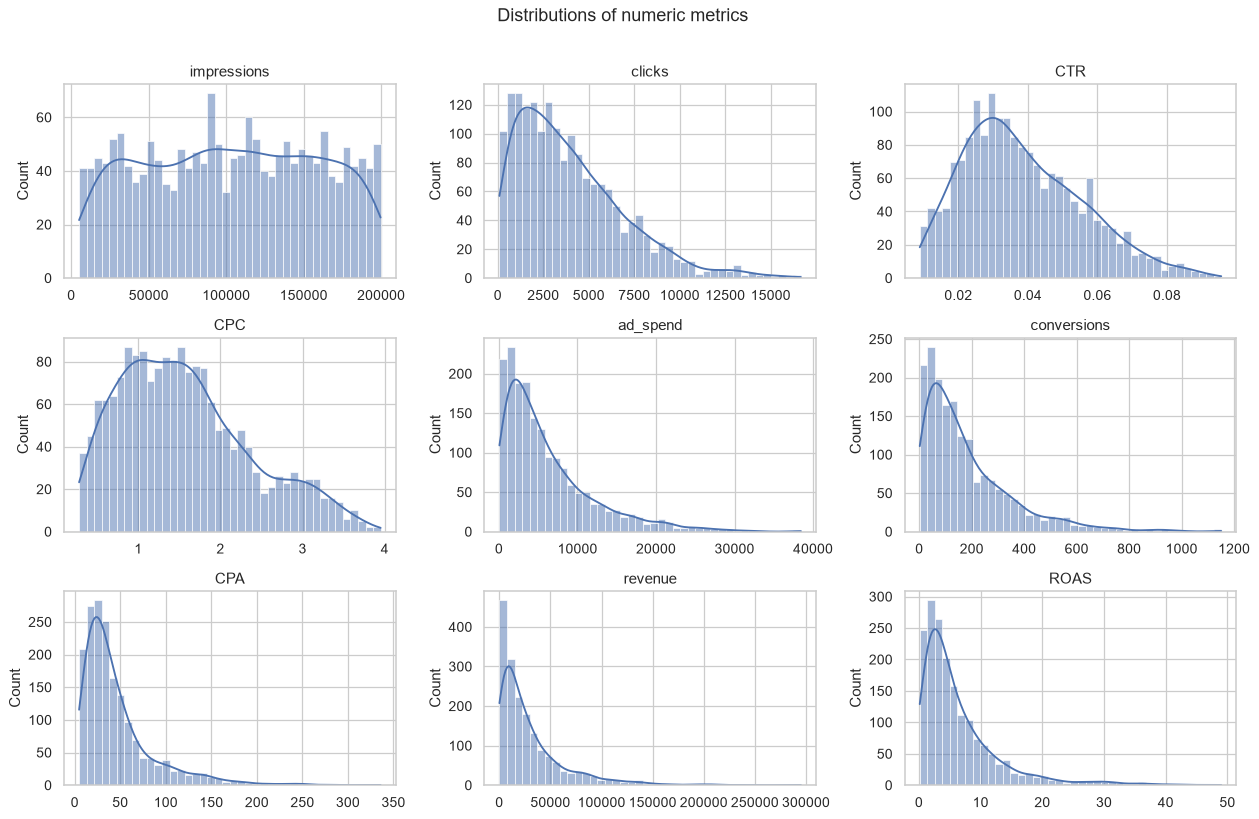

In [32]:
from scipy.stats import kde
fig, axes = plt.subplots(3, 3, figsize=(14,9))

for ax, c in zip(axes.ravel(), num_cols): 
    sns.histplot(df[c], bins=40, ax=ax, kde=True)
    ax.set_title(c)
    ax.set_xlabel('')

plt.suptitle('Distributions of numeric metrics', y=1.01)
plt.tight_layout() 
plt.show() 

*Right-skewed money metrics on a log scale become near-normal -> log transforms will help our models later* 

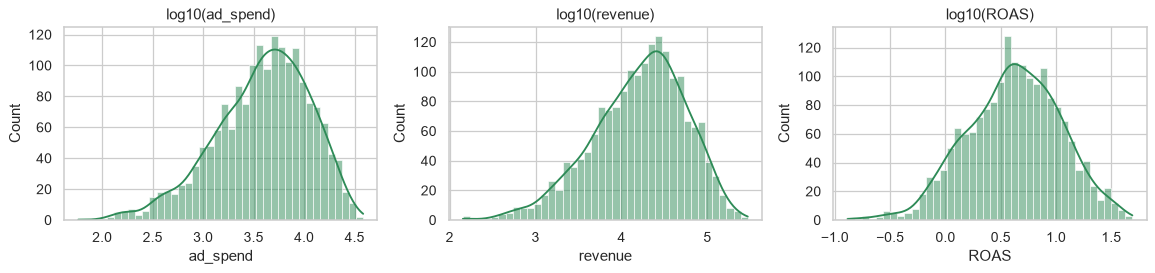

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(13,3.2))

for ax, c in zip(axes, ['ad_spend','revenue','ROAS']): 
    sns.histplot(np.log10(df[c]),bins=40, ax=ax, kde=True, color='seagreen')
    ax.set_title(f'log10({c})')

plt.tight_layout() 
plt.show()

fig, axes = plt.subplots()

### Reporting: 

* Report medians, not means. Saying "our average ROAS is 6.45" overstates typical performance by ~50%. A stakeholder planning around 6.45 will be disappointed; 4.3 is the honest expectation.




* Business reading: ad performance is a "hits business." A minority of campaigns produce outsized revenue (this is why our `Pareto analysis` found 41% of campaigns making 80% of revenue). The tail is the business.

**Note for modeling:** 
- Modeling consequences (ties into the course): the squared error cost punishes big errors quadratically, so a handful of $295k campaigns dominate the cost function — gradient descent bends the line to chase outliers. That's why the notebook showed log1p(revenue) and log1p(ROAS): the log compresses the long tail into a near-normal shape, giving better-behaved regression.
- Statistics consequences: tests that assume normality (plain t-tests, standard confidence intervals) are unreliable on skew-2.4 data — which is exactly why the notebook used the Kruskal–Wallis test and why we ran ANOVA on log(ROAS) rather than raw ROAS.
